In [18]:
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [19]:
tables = ['job_order_services','job_orders', 'services', 'vehicles']

dataframes = {}
for table in tables:
    csv_path = f'../../CSV_FILES/{table}.csv'
    if os.path.exists(csv_path):
        try:
            dataframes[table] = pd.read_csv(csv_path)
            print(f"Table: {table}, {len(dataframes[table])} rows")
        except Exception as e:
            print(f"Error:{e}")
            print(f"Problem loading table: {table}")
        finally:
            print("Finished")
    else:
        print(f"Path {os.path.abspath(csv_path)} does not exist")

Table: job_order_services, 2638 rows
Finished
Table: job_orders, 1500 rows
Finished
Table: services, 30 rows
Finished
Table: vehicles, 1200 rows
Finished


In [20]:
# Checking each table
for name, df in dataframes.items():
    print(f"table {name}: {df.shape[0]} rows")
    print(f"Columns: {', '.join(df.columns.tolist())}\n")


table job_order_services: 2638 rows
Columns: id, job_order_id, service_id, description_of_work, estimated_duration, actual_duration, amount

table job_orders: 1500 rows
Columns: id, ticket_id, user_id, vehicle_id, jo_date, date_arrived, date_promised, started_at, completed_at, released_at, estimated_duration, actual_duration, grand_total, partial_payment, balance, status

table services: 30 rows
Columns: id, shop_id, service_name, description, base_price, base_duration_hours, is_price_fixed, is_active

table vehicles: 1200 rows
Columns: id, user_id, vin, plate_number, vehicle_model, vehicle_year, vehicle_type



In [21]:
# Change datetime (or time) in string vers to minutes
def durations_to_minutes(duration):
    if pd.isna(duration):
        return np.nan
    
    d = str(duration).strip()
    # "X days HH:MM:SS"
    match = re.match(r'(\d+)\s+days\s+(\d+):(\d+):(\d+)', d)
    if match:
        days, hours, mins, secs = map(int, match.groups())
        return days * 24 * 60 + hours * 60 + mins + (secs/60)
    # "HH:MM:SS"
    match = re.match(r'(\d+):(\d+):(\d+)', d)
    if match:
        hours, mins, secs = map(int, match.groups())
        return hours * 60 + mins + (secs/60)
    return np.nan



In [22]:
# Testing
test_cases = ["0 days 02:30:45", "1 days 00:15:00", "03:45:30"]
for t in test_cases:
    print(f" '{t}' = {durations_to_minutes(t)} minutes")


 '0 days 02:30:45' = 150.75 minutes
 '1 days 00:15:00' = 1455.0 minutes
 '03:45:30' = 225.5 minutes


In [23]:
# Dataframes
job_order_services = dataframes['job_order_services'].copy()
services = dataframes['services'].copy()
job_orders = dataframes['job_orders'].copy()
vehicles = dataframes['vehicles'].copy()

# Parsing 
job_order_services['estimated_duration_mins'] = job_order_services['estimated_duration'].apply(durations_to_minutes)
job_order_services['actual_duration_mins'] = job_order_services['actual_duration'].apply(durations_to_minutes)

# Merging
full_data = job_order_services.merge(
    services[['id', 'base_price', 'base_duration_hours', 'is_price_fixed']],
    left_on = 'service_id', right_on = 'id', how='left', suffixes=('','_s') 
)

full_data = full_data.merge(
    job_orders[['id', 'vehicle_id']].rename(columns={'id':'jo_id'}),
    left_on = 'job_order_id', right_on = 'jo_id', how = 'left'
)

full_data = full_data.merge(
    vehicles[['id', 'vehicle_year', 'vehicle_type']].rename(columns={'id': 'veh_id'}),
    left_on='vehicle_id', right_on='veh_id', how='left'
)



# vehicle age & encoder
full_data['vehicle_age'] = pd.Timestamp.now().year - full_data['vehicle_year']
veh_type_encoder = LabelEncoder()
full_data['vehicle_type_encoded'] = veh_type_encoder.fit_transform(full_data['vehicle_type'].fillna('Unknown'))

# Features and target
features = ['estimated_duration_mins', 'amount', 'service_id',
                 'base_price', 'base_duration_hours', 'is_price_fixed',
                 'vehicle_age', 'vehicle_type_encoded']

target = 'actual_duration_mins'

df = full_data[features + [target]].dropna()
print(f"Columns: {full_data.columns.tolist()}")
print(f"Rows: {full_data.shape[0]}")
print(f"Target: {target}")
print(f"Analytics:")
df.describe().round(2)

Columns: ['id', 'job_order_id', 'service_id', 'description_of_work', 'estimated_duration', 'actual_duration', 'amount', 'estimated_duration_mins', 'actual_duration_mins', 'id_s', 'base_price', 'base_duration_hours', 'is_price_fixed', 'jo_id', 'vehicle_id', 'veh_id', 'vehicle_year', 'vehicle_type', 'vehicle_age', 'vehicle_type_encoded']
Rows: 2638
Target: actual_duration_mins
Analytics:


,estimated_duration_mins,amount,service_id,base_price,base_duration_hours,is_price_fixed,vehicle_age,vehicle_type_encoded,actual_duration_mins
count,2638.00,2638.00,2638.00,2638.00,2638.00,2638.00,2638.00,2638.00,2638.00
mean,225.83,8040.34,15.43,7135.07,3.77,0.51,4.95,3.46,289.57
std,276.01,10133.08,8.92,8884.01,4.59,0.50,2.95,1.51,361.33
min,32.73,931.00,1.00,1165.09,0.64,0.00,1.00,0.00,30.57
25%,84.04,2685.00,7.00,2363.89,1.37,0.00,3.00,2.00,105.87
50%,137.64,4608.00,16.00,4081.11,2.39,1.00,4.00,4.00,170.78
75%,246.72,9027.50,23.00,7878.34,3.98,1.00,7.00,5.00,325.96
max,1674.40,67562.00,30.00,45909.89,24.32,1.00,14.00,6.00,2636.22


In [24]:
# Split data
X_time = df[features]
y_time = df[target]

# train_test_split
X_time_train, X_time_test, y_time_train, y_time_test = train_test_split(
    X_time, y_time, test_size=0.2, random_state=27
)

# RandomForestRegressor
rf_time = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_time.fit(X_time_train, y_time_train)

# Train & Test prediction
y_time_pred_train = rf_time.predict(X_time_train)
y_time_pred_test = rf_time.predict(X_time_test)

# Analytics
mse_train = mean_squared_error(y_time_train, y_time_pred_train)
mse_test = mean_squared_error(y_time_test, y_time_pred_test)
print(f"{'Metric':<30} {'Train':>10} {'Test':>10}")
print(f"{'-'*50}")
print(f"  {'MSE':<30} {mse_train:>10.2f} {mse_test:>10.2f}")
print(f"  {'RMSE':<30} {np.sqrt(mse_train):>10.2f} {np.sqrt(mse_test):>10.2f}")
print(f"  {'MAE':<30} {mean_absolute_error(y_time_train, y_time_pred_train):>10.2f} {mean_absolute_error(y_time_test, y_time_pred_test):>10.2f}")
print(f"  {'R2_Score':<30} {r2_score(y_time_train, y_time_pred_train):>10.4f} {r2_score(y_time_test, y_time_pred_test):>10.4f}")

Metric                              Train       Test
--------------------------------------------------
  MSE                                514.48    5143.13
  RMSE                                22.68      71.72
  MAE                                 12.22      36.20
  R2_Score                           0.9960     0.9615



Feature Importances:
                   Feature  Importance
0  estimated_duration_mins    0.456940
4      base_duration_hours    0.256909
3               base_price    0.235156
1                   amount    0.030337
6              vehicle_age    0.007859
2               service_id    0.007435
7     vehicle_type_encoded    0.005326
5           is_price_fixed    0.000038


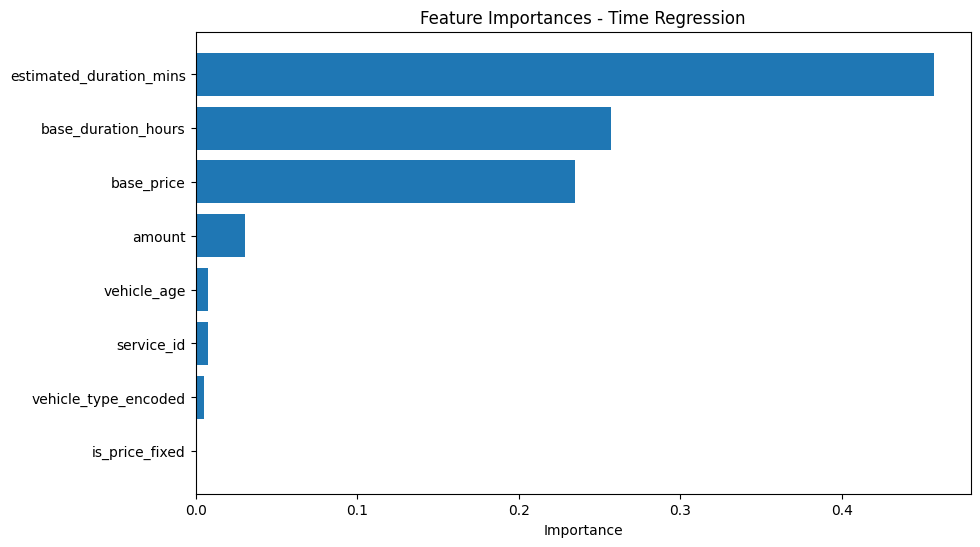

In [25]:
# Feature Importances
importances = rf_time.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("\nFeature Importances:")
print(feat_imp_df)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances - Time Regression')
plt.xlabel('Importance')
plt.show()


In [26]:
# Save predictions for the next step in the pipeline (Cost Model)
df['predicted_duration_mins'] = rf_time.predict(X_time)
df.to_csv('pipeline_time_output.csv', index=False)
print("Saved time predictions to pipeline_time_output.csv")


Saved time predictions to pipeline_time_output.csv


Loaded 2638 rows from pipeline_time_output.csv
Metric                              Train       Test
--------------------------------------------------
  MSE                             514725.20 3722711.67
  RMSE                               717.44    1929.43
  MAE                                378.07    1011.32
  R2_Score                           0.9950     0.9618

Feature Importances (Cost Model):
                   Feature  Importance
0  predicted_duration_mins    0.409942
1               base_price    0.352429
2      base_duration_hours    0.218542
5     vehicle_type_encoded    0.011414
4              vehicle_age    0.007627
3           is_price_fixed    0.000045


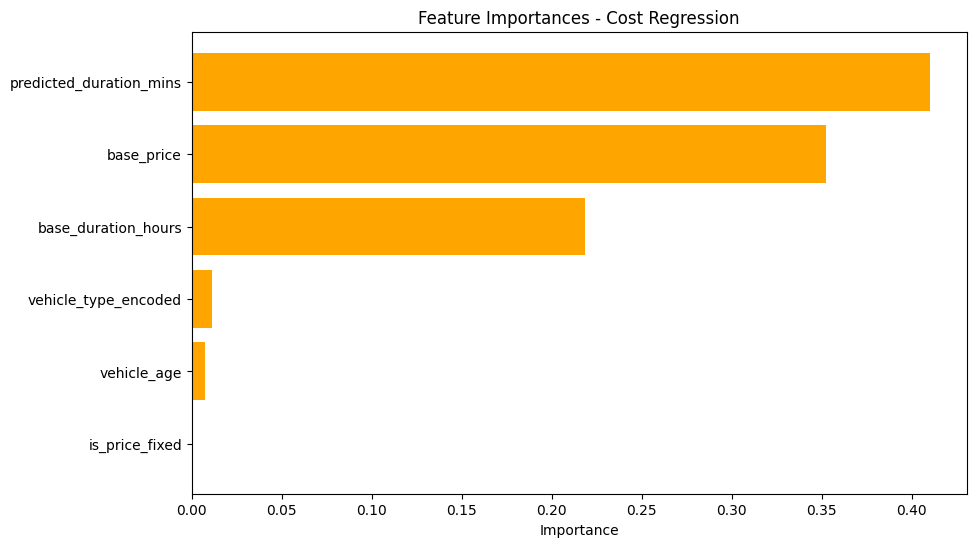

Saved cost predictions to pipeline_cost_output.csv
Loaded 2638 rows from pipeline_cost_output.csv
Churn Distribution:
is_churned
0    2530
1     108
Name: count, dtype: int64

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       505
           1       0.94      0.74      0.83        23

    accuracy                           0.99       528
   macro avg       0.97      0.87      0.91       528
weighted avg       0.99      0.99      0.99       528

Metric                    Train       Test
------------------------------------------
  Accuracy                 1.0000     0.9867
  F1 Score                 1.0000     0.8293


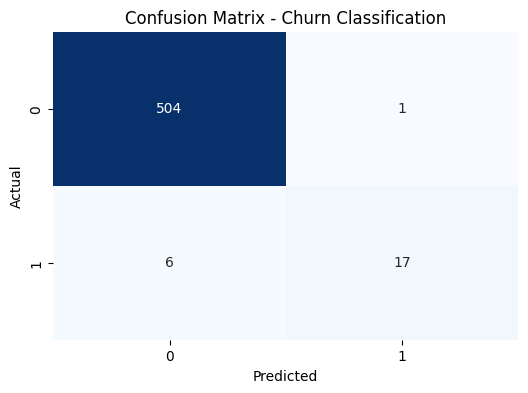


Feature Importances (Churn Model):
                   Feature  Importance
0  predicted_duration_mins    0.334947
1         predicted_amount    0.291712
3      base_duration_hours    0.196049
2               base_price    0.160454
4              vehicle_age    0.009545
5     vehicle_type_encoded    0.007293


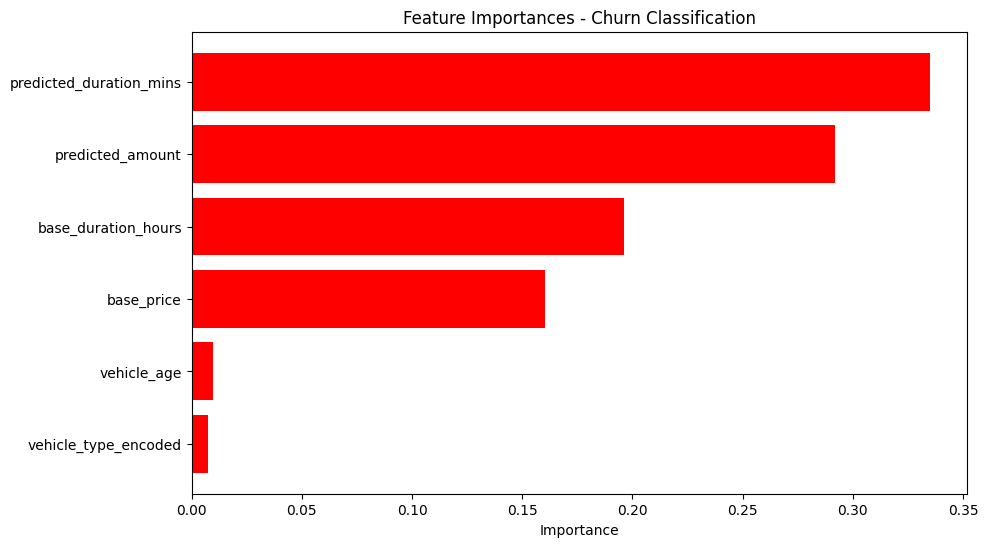


--- PIPELINE EXECUTION COMPLETED SUCCESSFULLY ---


In [27]:
# Call the next model in the pipeline
%run cost_regression.ipynb


In [ ]:
import joblib
joblib.dump(rf_time, 'exported/time_model.pkl')
joblib.dump(veh_type_encoder, 'exported/veh_type_encoder.pkl')